# TP8 - Paul Rongieras

**Context**: In this TP, we will use MedMNIST, a large-scale MNIST-like collection of standardized biomedical images, including 12 datasets for 2D and 6 datasets for 3D. All images are pre-processed into different sizes: 28x28, 64x64, 128x128 and 256x256 with the corresponding classification labels. The size of the datasets varies from 100 to 100,000 images with different tasks, in particular: binary/multi-class.

**Goal**: Implement and use at **two**  explainability methods seen during the lecture of today (e.g., Attribution, CAM, LIME) on at least **two** different networks and **two** MedMNIST datasets (e.g., PathMNISt and DermaMNIST). You can use the image size you want (the bigger, the easier to interpret but the more computational capability you will need, please choose according to your computational capability).

**Implementation**: for complex methods ([SHAP](https://shap.readthedocs.io/en/latest/), [LRP](https://github.com/sebastian-lapuschkin/lrp_toolbox), [Integrated Gradients](https://captum.ai/docs/introduction), DeepLIFT) you can use existing implementations. See also: https://github.com/interpretml/interpret, https://github.com/marcoancona/DeepExplain

**Deadline**: Please check on the course website.

In [2]:
# In this notebook, we use data loaders with heavier computational processing. It is recommended to use as many
# workers as possible in a data loader, which corresponds to the number of CPU cores
import os
import numpy as np
import torch
NUM_WORKERS = os.cpu_count()
print("Number of workers:", NUM_WORKERS)

# Ensure that all operations are deterministic on GPU (if used) for reproducibility
torch.backends.cudnn.determinstic = True
torch.backends.cudnn.benchmark = False

# For reproducibility
np.random.seed(666)
torch.manual_seed(666)


try:
  import google.colab
  IN_COLAB = True
  !pip install medmnist
except:
  IN_COLAB = False

Number of workers: 4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 4.5 MB/s eta 0:00:00


In [3]:
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torch.utils.data as data
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
from torchvision.models import resnet18, resnet50, ResNet18_Weights
from tqdm import trange

import medmnist
from medmnist import INFO, Evaluator

import matplotlib.pyplot as plt
from PIL import Image
from skimage.segmentation import quickshift

print(f"MedMNIST v{medmnist.__version__} @ {medmnist.HOMEPAGE}")

MedMNIST v3.0.2 @ https://github.com/MedMNIST/MedMNIST/


In [4]:
print("Using torch", torch.__version__)

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print ("MPS device found.")
elif torch.cuda.is_available():
    device = torch.device("cuda:0") # we use one GPU, the first one
    print ("CUDA device found.")
else:
   device = torch.device("cpu")
   print('No MPS or CUDA has been found. PyTorch will use CPU.')

Using torch 2.9.0+cu126
CUDA device found.


Here you can choose which dataset you want to use and the image size. Please use 28x28 at the beginning. Change the batch size according to your computational capability (1024 is good for Google Colab)

In [5]:
# Dataset Hyper-parameters
dataset_name = "pathmnist"  # Change this to any MedMNIST dataset (e.g., "chestmnist", "bloodmnist")
SIZE_IMAGES=28 # 28, 64, 128, 256
BATCH_SIZE = 1024

Here we download the data and create the datasets and loaders.

In [6]:
# Function to load any MedMNIST dataset
def load_medmnist(dataset_name, BATCH_SIZE, SIZE_IMAGES):
    info = INFO[dataset_name]
    num_classes = len(info["label"])
    in_channels = 3 if info["n_channels"] == 3 else 1  # Handle grayscale & RGB

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5] * in_channels, std=[0.5] * in_channels)
    ])

    DataClass = getattr(medmnist, info["python_class"])

    train_dataset = DataClass(split="train", transform=transform, download=True, size=SIZE_IMAGES)
    val_dataset = DataClass(split="val", transform=transform, download=True, size=SIZE_IMAGES)
    test_dataset = DataClass(split="test", transform=transform, download=True, size=SIZE_IMAGES)

    train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
    val_loader = DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)
    test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

    task=info['task']

    return train_dataset, val_dataset, test_dataset,  train_loader, val_loader, test_loader, in_channels, num_classes, task

Here you can check the task, the number of data and verify the image size.

In [7]:
# Run training on any MedMNIST dataset
train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader, in_channels, num_classes, task = load_medmnist(dataset_name, BATCH_SIZE, SIZE_IMAGES)

print('The task is', task)
# Get image size from the dataset
image_size = train_loader.dataset.imgs.shape[1]  # Works for all MedMNIST datasets
print('The size of images is ', image_size)

100%|██████████| 206M/206M [00:15<00:00, 13.3MB/s] 


The task is multi-class
The size of images is  28


In [8]:
print(train_dataset)
print("===================")
print(val_dataset)
print("===================")
print(test_dataset)

Dataset PathMNIST of size 28 (pathmnist)
    Number of datapoints: 89996
    Root location: /root/.medmnist
    Split: train
    Task: multi-class
    Number of channels: 3
    Meaning of labels: {'0': 'adipose', '1': 'background', '2': 'debris', '3': 'lymphocytes', '4': 'mucus', '5': 'smooth muscle', '6': 'normal colon mucosa', '7': 'cancer-associated stroma', '8': 'colorectal adenocarcinoma epithelium'}
    Number of samples: {'train': 89996, 'val': 10004, 'test': 7180}
    Description: The PathMNIST is based on a prior study for predicting survival from colorectal cancer histology slides, providing a dataset (NCT-CRC-HE-100K) of 100,000 non-overlapping image patches from hematoxylin & eosin stained histological images, and a test dataset (CRC-VAL-HE-7K) of 7,180 image patches from a different clinical center. The dataset is comprised of 9 types of tissues, resulting in a multi-class classification task. We resize the source images of 3×224×224 into 3×28×28, and split NCT-CRC-HE-100K

The authors of MedMNIST has created a function to plot the images.

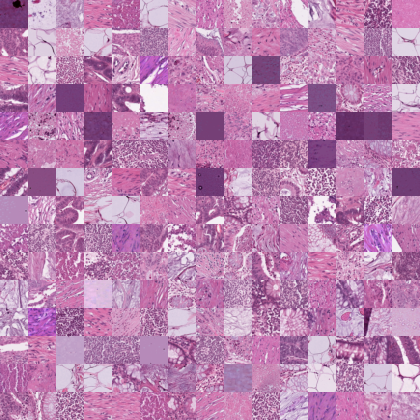

In [9]:
# montage
train_dataset.montage(length=15)

Please change the Number of epochs to 1 or 2 to test the code.

In [22]:
# Optimization Hyper-parameters
NUM_EPOCHS = 50
lr = 0.001

At first, we will use a very simple network proposed by the authors of MedMNIST. Look at it carefully. You will change it later on.

In [13]:
# define a simple CNN model (from MedMNIST website)
class Net(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(Net, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3),
            nn.BatchNorm2d(16),
            nn.ReLU())

        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=3),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))

        self.layer3 = nn.Sequential(
            nn.Conv2d(16, 64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU())

        self.layer4 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU())

        self.layer5 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))

        self.fc = nn.Sequential(
            nn.Linear(64 * 4 * 4, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes))

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x


We can initalize the model and train it.

In [14]:
# Initialize model
model = Net(in_channels=in_channels, num_classes=num_classes)

**Question**: Look at the training and validation code. Why do we separate for binary and multi class ?

In [15]:
# Training Function
def train_model(model, train_loader, val_loader, task, num_epochs, lr):
    model.to(device)

    # Choose loss function based on the task type
    if task == "multi-label, binary-class":
        criterion = nn.BCEWithLogitsLoss().to(device)
    else: # multi-class
        criterion = nn.CrossEntropyLoss().to(device)

    optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)

    # Training loop
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0

        for images, labels in tqdm(train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)

            if task == "multi-label, binary-class":
              labels = labels.to(torch.float32)  # Ensure float for BCEWithLogitsLoss
            else: # multi-class
              labels = labels.squeeze().long() # Convert one-hot to class index

            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

            # Compute Accuracy for CrossEntropyLoss or BCEWithLogitsLoss
            if task == "multi-label, binary-class":  # Binary classification
                outputs = torch.sigmoid(outputs)  # Apply sigmoid for binary classification
                predicted = (outputs >= 0.5).long()  # Threshold at 0.5 for binary classification
            else:  # Multi-class classification
                _, predicted = torch.max(outputs, 1)  # Get predicted class index

            correct += (predicted == labels).sum().item()
            total += labels.size(0)


        accuracy = 100 * correct / total
        print(f"Epoch {epoch+1}/{num_epochs}, Loss: {running_loss/len(train_loader):.4f}, Accuracy: {accuracy:.2f}%")


        # Validation phase
        model.eval()  # Set model to evaluation mode (disables dropout, batchnorm, etc.)
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():  # No need to compute gradients for validation
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                if task == "multi-label, binary-class":
                  labels = labels.to(torch.float32)  # Ensure float for BCEWithLogitsLoss
                else:
                  labels = labels.squeeze().long() # Convert one-hot to class index

                loss = criterion(outputs, labels)

                val_loss += loss.item()

                # Compute Accuracy for CrossEntropyLoss or BCEWithLogitsLoss
                if task == "multi-label, binary-class":  # Binary classification
                    outputs = torch.sigmoid(outputs)  # Apply sigmoid for binary classification
                    predicted = (outputs >= 0.5).long()  # Threshold at 0.5 for binary classification
                else:  # Multi-class classification
                    _, predicted = torch.max(outputs, 1)

                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        # Compute validation accuracy
        val_accuracy = 100 * val_correct / val_total
        print(f"Epoch {epoch+1}/{num_epochs}, Val Loss: {val_loss/len(test_loader):.4f}, Val Accuracy: {val_accuracy:.2f}%")

    return model


You can now train your model.

In [23]:
trained_model = train_model(model, train_loader, val_loader, task, NUM_EPOCHS, lr)

100%|██████████| 88/88 [00:26<00:00,  3.36it/s]


Epoch 1/50, Loss: 1.1034, Accuracy: 58.67%
Epoch 1/50, Val Loss: 1.2754, Val Accuracy: 61.66%


100%|██████████| 88/88 [00:29<00:00,  2.96it/s]


Epoch 2/50, Loss: 0.9274, Accuracy: 65.03%
Epoch 2/50, Val Loss: 1.0912, Val Accuracy: 66.69%


100%|██████████| 88/88 [00:28<00:00,  3.11it/s]


...

Epoch 48/50, Loss: 0.1483, Accuracy: 94.91%
Epoch 48/50, Val Loss: 0.2856, Val Accuracy: 92.29%


100%|██████████| 88/88 [00:26<00:00,  3.37it/s]


Epoch 49/50, Loss: 0.1448, Accuracy: 95.11%
Epoch 49/50, Val Loss: 0.2723, Val Accuracy: 92.68%


100%|██████████| 88/88 [00:25<00:00,  3.39it/s]


Epoch 50/50, Loss: 0.1405, Accuracy: 95.27%
Epoch 50/50, Val Loss: 0.3103, Val Accuracy: 91.56%


In [24]:
#save model checkpoints
os.makedirs('models/', exist_ok=True)
filename = 'models/PathMNIST_'+ str(SIZE_IMAGES) +'_'+ str(NUM_EPOCHS) +'.pth.tar'
torch.save({
                'epoch': NUM_EPOCHS,
                'state_dict': trained_model.state_dict()
            }, filename)

And evaluate it.

In [10]:
# Evaluation
def evaluate(model, test_loader, task):
    model.eval()
    y_true = []  # Store true labels
    pred = []  # Store predicted classes
    test_correct = 0
    test_total = 0

    with torch.no_grad():
      for images, labels in test_loader:
          images, labels = images.to(device), labels.to(device)
          outputs = model(images)

          if task == "multi-label, binary-class":
            labels = labels.to(torch.float32)  # Ensure float for BCEWithLogitsLoss
            outputs = torch.sigmoid(outputs)  # Apply sigmoid for binary classification
            predicted = (outputs >= 0.5).long()  # Threshold at 0.5 for binary classification
          else:
            labels = labels.squeeze().long() # Convert one-hot to class index
            _, predicted = torch.max(outputs, 1)  # Get predicted class index

          test_correct += (predicted == labels).sum().item()
          test_total += labels.size(0)

          # Collect the results
          y_true.append(labels.cpu().numpy())
          pred.append(predicted.cpu().numpy())

    # Convert to numpy arrays after gathering all results
    y_true = np.concatenate(y_true, axis=0)
    pred = np.concatenate(pred, axis=0)

    test_accuracy = 100 * test_correct / test_total
    print(f"Test Accuracy: {test_accuracy:.2f}%")

    # Compute test accuracy
    #acc = np.sum(y_true.flatten() == pred.flatten())/len(pred)*100
    #print(f"Test Accuracy: {acc:.2f}%")

    return y_true, pred

In [26]:
y_true,pred = evaluate(trained_model, test_loader, task)

correct_images=np.where(y_true.flatten() == pred.flatten())[0]
wrong_images=np.where(~(y_true.flatten() == pred.flatten()))[0]

Test Accuracy: 81.39%


**Question**: Train it for at least 50 epochs and look at the training/validation evolution and then at the test score. Are you satisfied ? If not, what would you change ?

**Answer**: First of all, the train accuracy is logically increasing among epochs to achieve 95.27%. Concerning the validation set, it is globally increasing too with few drops, to achieve 91,56% at the last epoch. Unfortunately, we achieved only 81,39% of test accuracy, which is not that high and confirm the hypothesis of overfitting on both the training set and the validation set. To avoid that, I would add some dropout in the network and early stopping during the training process.

Let's look at some correctly classified and wrongly classified images.

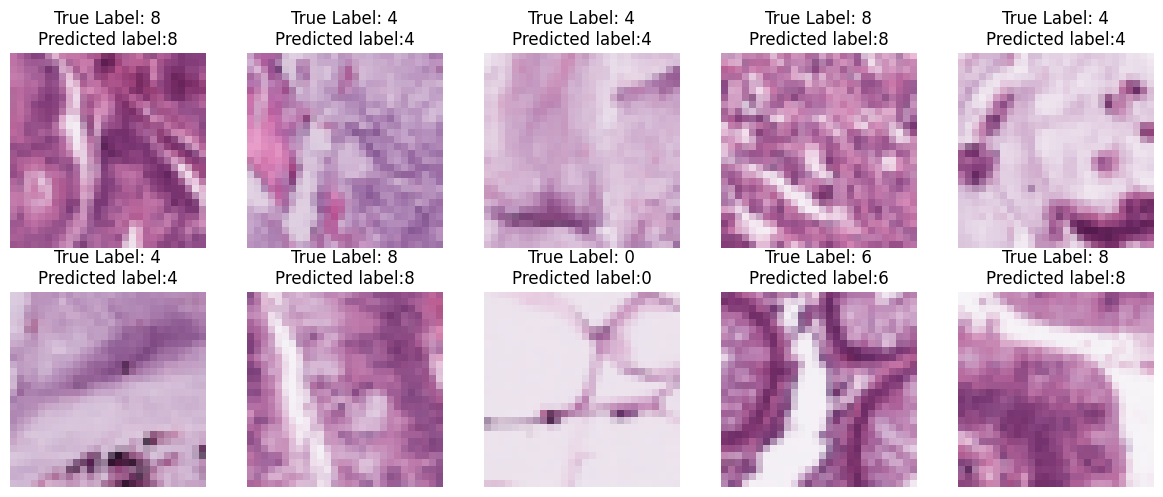

In [27]:
# Correctly classified
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

# Flatten axes for easy iteration
axes = axes.flatten()

selected_indices = correct_images[:10]

# Iterate through the selected indices
for i, idx in enumerate(selected_indices):
    image, label = test_loader.dataset[idx]  # Extract image and label

    # If image is RGB, swap dimensions from (C, H, W) to (H, W, C)
    mean=torch.tensor([.5])
    std=torch.tensor([.5])
    unnormalize = transforms.Normalize((-mean / std).tolist(), (1.0 / std).tolist())
    img = np.clip(unnormalize(image).numpy(),0,1)
    img = img.transpose(1, 2, 0)  # Convert from PyTorch format to Matplotlib format

    axes[i].imshow(img)  # Adjust cmap if necessary
    axes[i].set_title(f"True Label: {label[0]}\nPredicted label:{pred[idx]}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

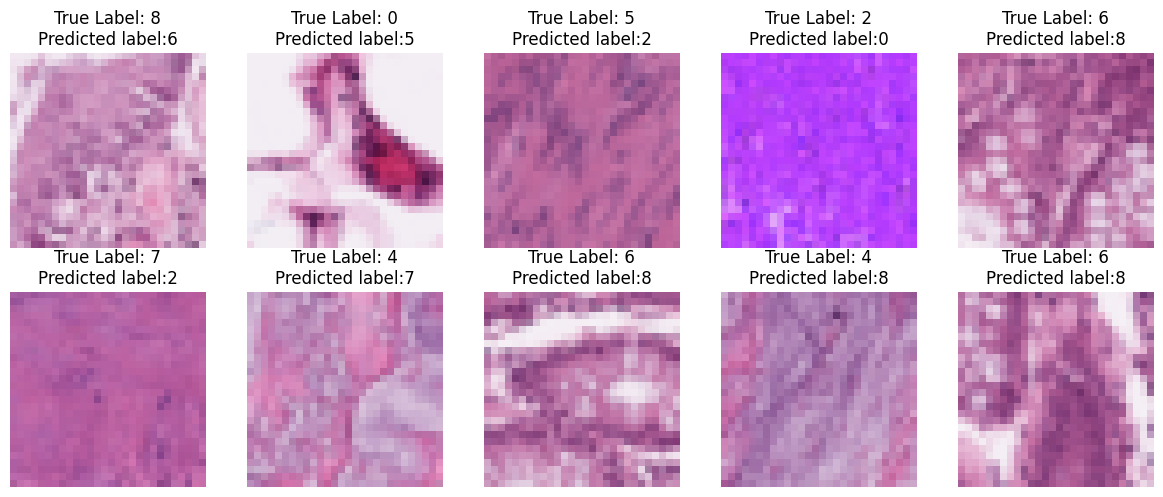

In [28]:
# Wrongly classified
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

# Flatten axes for easy iteration
axes = axes.flatten()

selected_indices = wrong_images[:10]

# Iterate through the selected indices
for i, idx in enumerate(selected_indices):
    image, label = test_loader.dataset[idx]  # Extract image and label

    # If image is RGB, swap dimensions from (C, H, W) to (H, W, C)
    mean=torch.tensor([.5])
    std=torch.tensor([.5])
    unnormalize = transforms.Normalize((-mean / std).tolist(), (1.0 / std).tolist())
    img = np.clip(unnormalize(image).numpy(),0,1)
    img = img.transpose(1, 2, 0)  # Convert from PyTorch format to Matplotlib format

    axes[i].imshow(img)  # Adjust cmap if necessary
    axes[i].set_title(f"True Label: {label[0]}\nPredicted label:{pred[idx]}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

**Question**: Can you see some patterns that could explain why the algorithm has wrongly classified these images ? At the lowest resolution (28x28) is very difficult (I would say impossible). Choose a higher resolution and train the same code.

**Answer**: Honestly at 28x28 resolution, I don't understand anything at what I am looking. We try a higher resolution: 64x64 (just to answer the question as the training process was a bit long with 28x28).

In [29]:
# Dataset Hyper-parameters
dataset_name = "pathmnist"  # Change this to any MedMNIST dataset (e.g., "chestmnist", "bloodmnist")
SIZE_IMAGES=64 # 28, 64, 128, 256
BATCH_SIZE = 1024

In [30]:
# Run training on any MedMNIST dataset
train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader, in_channels, num_classes, task = load_medmnist(dataset_name, BATCH_SIZE, SIZE_IMAGES)

print('The task is', task)
# Get image size from the dataset
image_size = train_loader.dataset.imgs.shape[1]  # Works for all MedMNIST datasets
print('The size of images is ', image_size)

100%|██████████| 1.07G/1.07G [00:38<00:00, 27.6MB/s]


The task is multi-class
The size of images is  64


In [31]:
# Initialize model
model = Net(in_channels=in_channels, num_classes=num_classes)

In [32]:
trained_model = train_model(model, train_loader, val_loader, task, NUM_EPOCHS, lr)

  0%|          | 0/88 [00:00<?, ?it/s]


RuntimeError: mat1 and mat2 shapes cannot be multiplied (1024x10816 and 1024x128)

**Question**: You probably found an error. Please change the `Net` code so that it can work with any input size. If you want to speed up computations, you can also change the number of channels. You can also change the optimization process if you wish.

**Answer**: This error is due to the linear layer of the CNN, which expects 28x28 images as input as the 5th convolution layer returns 4x4 with 64 channels, and the linear layer starts with 64x4x4. To fix it, we just add Global Average Pooling after the 5th convolution layer. Even if the training was slow, we don't change the number of channels as it will probably decrease performances such as accuracy. However, we modify the training process by adding Mixed Precision, and the use of AdamW instead of SGD. In addition, we add early stopping with a patience of 10.

In [11]:
# modified CNN model (that accepts every resolution)
class modified_Net(nn.Module):
    def __init__(self, in_channels, num_classes):
        super(modified_Net, self).__init__()

        self.layer1 = nn.Sequential(
            nn.Conv2d(in_channels, 16, kernel_size=3),
            nn.BatchNorm2d(16),
            nn.ReLU())

        self.layer2 = nn.Sequential(
            nn.Conv2d(16, 16, kernel_size=3),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))

        self.layer3 = nn.Sequential(
            nn.Conv2d(16, 64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU())

        self.layer4 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3),
            nn.BatchNorm2d(64),
            nn.ReLU())

        self.layer5 = nn.Sequential(
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2))

        # global average pooling
        self.gap = nn.AdaptiveAvgPool2d((1, 1))

        self.fc = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.layer5(x)
        x = self.gap(x)
        x = x.view(x.size(0), -1)
        x = self.fc(x)
        return x

In [12]:
def train_model(model, train_loader, val_loader, task, num_epochs, lr, weight_decay, patience):
    model.to(device)

    if task == "multi-label, binary-class":
        criterion = nn.BCEWithLogitsLoss().to(device)
    else: # multi-class
        criterion = nn.CrossEntropyLoss().to(device)

    # Optimizer and scheduler
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, 'min', patience=3, factor=0.1)

    scaler = torch.amp.GradScaler('cuda')

    best_val_loss = float('inf')
    patience_counter = 0
    model_path = 'best_model.pth'

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0

        # Training phase
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            images, labels = images.to(device), labels.to(device)

            if task == "multi-label, binary-class":
                labels = labels.to(torch.float32)
            else:
                labels = labels.squeeze().long()

            optimizer.zero_grad()

            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()

        # Validation phase
        model.eval()
        val_loss = 0.0
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                if task == "multi-label, binary-class":
                    labels = labels.to(torch.float32)
                else:
                    labels = labels.squeeze().long()

                with torch.amp.autocast('cuda'):
                    outputs = model(images)
                    v_loss = criterion(outputs, labels)

                val_loss += v_loss.item()

                if task == "multi-label, binary-class":
                    predicted = (torch.sigmoid(outputs) >= 0.5).long()
                else:
                    _, predicted = torch.max(outputs, 1)

                val_correct += (predicted == labels).sum().item()
                val_total += labels.size(0)

        avg_train_loss = running_loss / len(train_loader)
        avg_val_loss = val_loss / len(val_loader)
        val_accuracy = 100 * val_correct / val_total

        scheduler.step(avg_val_loss)
        current_lr = optimizer.param_groups[0]['lr']

        print(f"Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.2f}% | LR: {current_lr}")

        # Early stopping
        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            torch.save(model.state_dict(), model_path)
            print("Model saved (improved val loss)")
        else:
            patience_counter += 1
            print(f"No improvement. Patience: {patience_counter}/{patience}")
            if patience_counter >= patience:
                print("Early stopping triggered.")
                break

    print(f"Loading best weights from {model_path}...")
    model.load_state_dict(torch.load(model_path))

    return model

Let's train and evaluate it.

In [40]:
# Dataset Hyper-parameters
dataset_name = "pathmnist"  # Change this to any MedMNIST dataset (e.g., "chestmnist", "bloodmnist")
SIZE_IMAGES=28 # 28, 64, 128, 256
BATCH_SIZE = 1024

# Run training on any MedMNIST dataset
train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader, in_channels, num_classes, task = load_medmnist(dataset_name, BATCH_SIZE, SIZE_IMAGES)

print('The task is', task)
# Get image size from the dataset
image_size = train_loader.dataset.imgs.shape[1]  # Works for all MedMNIST datasets
print('The size of images is ', image_size)

The task is multi-class
The size of images is  28


In [50]:
# Initialize model
model = modified_Net(in_channels=in_channels, num_classes=num_classes)

In [51]:
# Optimization Hyper-parameters
NUM_EPOCHS = 50
lr = 0.001
weight_decay = 0.01
patience = 10

trained_model = train_model(model, train_loader, val_loader, task, NUM_EPOCHS, lr, weight_decay, patience)

Epoch 1: 100%|██████████| 88/88 [00:25<00:00,  3.50it/s]


Loss: 0.9851 | Val Loss: 0.6366 | Val Acc: 76.12% | LR: 0.001
Model saved (improved val loss)


Epoch 2: 100%|██████████| 88/88 [00:25<00:00,  3.49it/s]


Loss: 0.4947 | Val Loss: 0.5541 | Val Acc: 80.13% | LR: 0.001
Model saved (improved val loss)


Epoch 3: 100%|██████████| 88/88 [00:25<00:00,  3.41it/s]


...

Loss: 0.0466 | Val Loss: 0.1297 | Val Acc: 95.77% | LR: 1.0000000000000002e-06
No improvement. Patience: 8/10


Epoch 30: 100%|██████████| 88/88 [00:25<00:00,  3.50it/s]


Loss: 0.0463 | Val Loss: 0.1299 | Val Acc: 95.72% | LR: 1.0000000000000002e-06
No improvement. Patience: 9/10


Epoch 31: 100%|██████████| 88/88 [00:24<00:00,  3.55it/s]


Loss: 0.0460 | Val Loss: 0.1289 | Val Acc: 95.73% | LR: 1.0000000000000002e-06
No improvement. Patience: 10/10
Early stopping triggered.
Loading best weights from best_model.pth...


In [52]:
#save model checkpoints
os.makedirs('models/', exist_ok=True)
filename = 'models/PathMNIST_modNet'+ str(SIZE_IMAGES) +'_'+ str(NUM_EPOCHS) +'.pth.tar'
torch.save({
                'epoch': NUM_EPOCHS,
                'state_dict': trained_model.state_dict()
            }, filename)

In [53]:
y_true,pred = evaluate(trained_model, test_loader, task)

Test Accuracy: 81.42%


**Answer**: Even if it is not better than before despite the improvement in the training process, it works and we move on.

**Question**: Now that you have a working code. Implement and use **two**  explainability methods seen during the lecture of today (e.g., Attribution, CAM, LIME) on at least **two** different networks and **two** MedMNIST datasets (e.g., PathMNISt and DermaMNIST). You can use the image size you want (the bigger, the easier to interpret but the more computational capability you will need, please choose according to your computational capability).
As network, you can use the modified `Net` and either a pre-trained Pytorch one (such as ResNet) or another custom one of your choice.

**Answer**:

- Explainability methods used: Grad-CAM and Saliency Maps

- MedMNIST datasets: PathMNIST and DermaMNIST

- Networks: modified Net and pre-trained ResNet18

## Saliency Map:

In [13]:
def compute_saliency_map(model, image, target_class=None):
    model.eval()
    image.requires_grad_()

    output = model(image)

    if target_class is None:
        target_class = output.argmax(dim=1).item()

    model.zero_grad()
    output[0, target_class].backward()
    saliency = image.grad.data.abs().squeeze().max(dim=0)[0]
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)

    return saliency.cpu().numpy()


## Grad-CAM:

In [18]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        # we have to choose on which layer we want to apply Grad-CAM
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None
        self.target_layer.register_forward_hook(self.save_activation)
        self.target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, image, target_class=None):
        self.model.eval()

        output = self.model(image)

        if target_class is None:
            target_class = output.argmax(dim=1).item()

        self.model.zero_grad()
        output[0, target_class].backward()

        weights = torch.mean(self.gradients, dim=(2, 3), keepdim=True)
        grad_cam = torch.sum(weights * self.activations, dim=1, keepdim=True)
        grad_cam = F.relu(grad_cam)
        grad_cam = F.interpolate(grad_cam, size=image.shape[2:], mode='bilinear', align_corners=False)

        heatmap = grad_cam.squeeze().detach().cpu().numpy()
        heatmap = (heatmap - heatmap.min()) / (heatmap.max() - heatmap.min() + 1e-8)

        return heatmap

Visualisation of both methods side to side:

In [17]:
def visualize_explainability(model, dataset, target_layer, device, num_images):
    grad_cam = GradCAM(model, target_layer)

    fig, axes = plt.subplots(num_images, 3, figsize=(10, 3 * num_images))
    for i in range(num_images):
        img_tensor, label = dataset[i]
        img_tensor = img_tensor.unsqueeze(0).to(device)

        img_np = img_tensor.squeeze().cpu().numpy().transpose(1, 2, 0)
        img_np = (img_np - img_np.min()) / (img_np.max() - img_np.min() + 1e-8)

        saliency = compute_saliency_map(model, img_tensor)
        heatmap = grad_cam(img_tensor)

        axes[i, 0].imshow(img_np)
        axes[i, 0].set_title(f"Original (Class: {label})")
        axes[i, 0].axis('off')

        axes[i, 1].imshow(saliency, cmap='hot')
        axes[i, 1].set_title("Saliency Map")
        axes[i, 1].axis('off')

        axes[i, 2].imshow(img_np)
        axes[i, 2].imshow(heatmap, cmap='jet', alpha=0.5)
        axes[i, 2].set_title("Grad-CAM")
        axes[i, 2].axis('off')

    plt.tight_layout()
    plt.show()

# I. PathMNIST

In [19]:
dataset_name = "pathmnist"
SIZE_IMAGES=28
BATCH_SIZE = 1024

train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader, in_channels, num_classes, task = load_medmnist(dataset_name, BATCH_SIZE, SIZE_IMAGES)

print('The task is', task)
image_size = train_loader.dataset.imgs.shape[1]
print('The size of images is ', image_size)

The task is multi-class
The size of images is  28


## I.A. modified Net

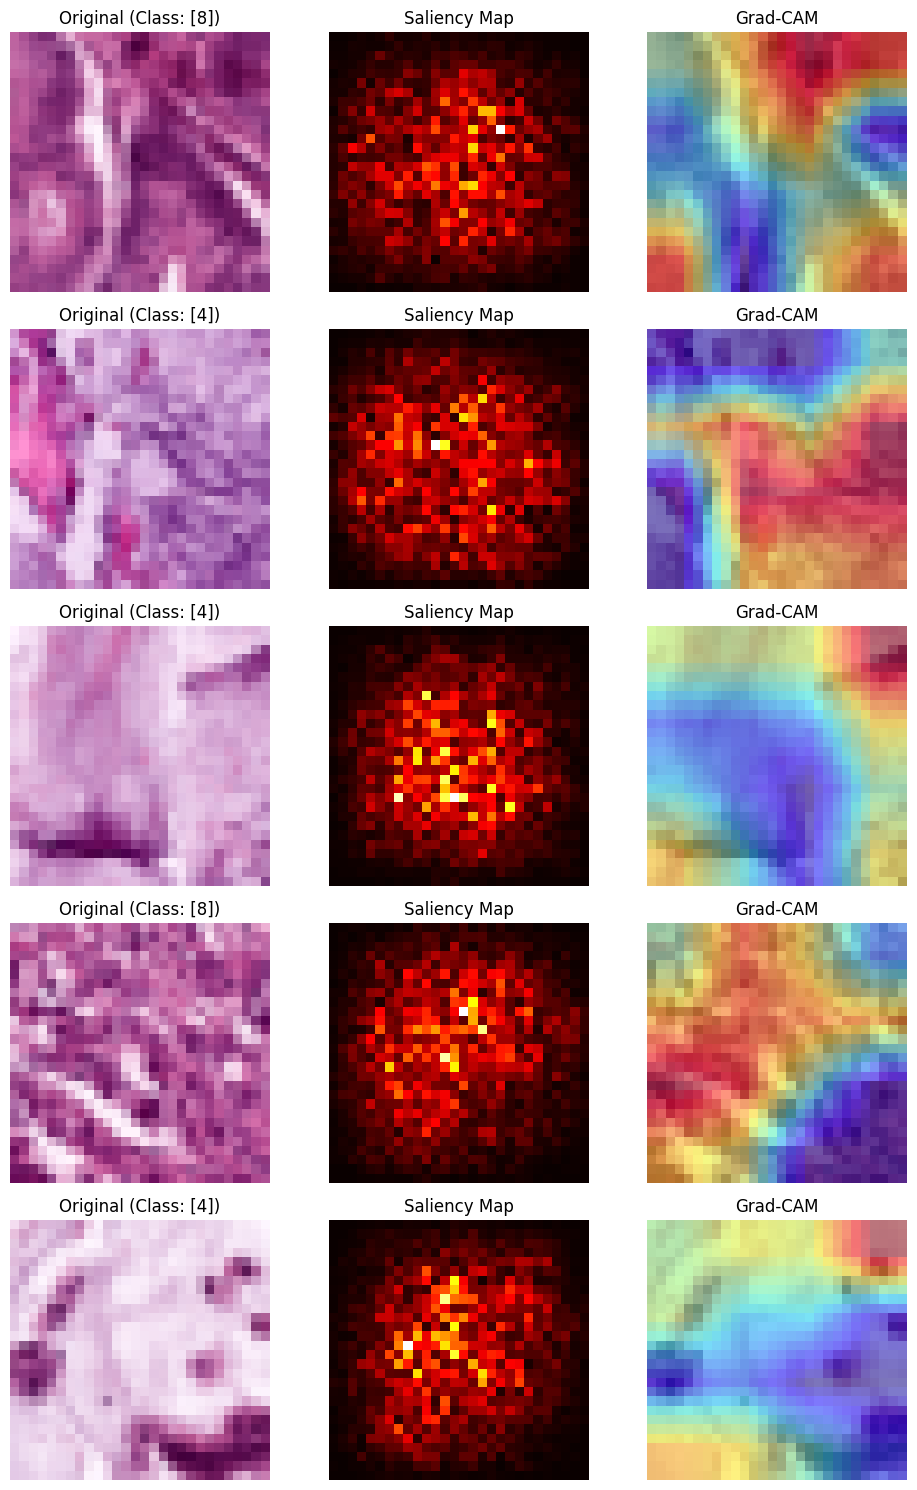

In [21]:
model_path = modified_Net(in_channels=in_channels, num_classes=num_classes)

# we reload the weights
checkpoint = torch.load('/kaggle/input/models/paulrongieras/model-tp8/pytorch/default/1/PathMNIST_modNet28_50.pth.tar', map_location=torch.device('cpu'))

if 'state_dict' in checkpoint:
    model_path.load_state_dict(checkpoint['state_dict'])
else:
    model_path.load_state_dict(checkpoint)

model_path.to(device)

# We choose to focus on the last layer as it probably contains the higher level features
visualize_explainability(model_path, test_dataset, model_path.layer5, device, num_images=5)

## I.B. pre-trained ResNet18

In [22]:
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

# We have to change the first convolution layer as the pre-trained model normally
# accept 224x224 images. Of course it will decrease a lot the benefit from the
# pre-training.

# The other option was to resize images to 224x224, but we are afraid by the
# computation time it could represent.
model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model.maxpool = nn.Identity()

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, num_classes)

NUM_EPOCHS = 50
lr = 0.001
weight_decay = 0.01
patience = 15

trained_model = train_model(model, train_loader, val_loader, task, NUM_EPOCHS, lr, weight_decay, patience)

os.makedirs('models/', exist_ok=True)
filename = 'models/PathMNIST_ResNet'+ str(SIZE_IMAGES) +'_'+ str(NUM_EPOCHS) +'.pth.tar'
torch.save({
                'epoch': NUM_EPOCHS,
                'state_dict': trained_model.state_dict()
            }, filename)

y_true,pred = evaluate(trained_model, test_loader, task)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 155MB/s] 
Epoch 1: 100%|██████████| 88/88 [00:39<00:00,  2.22it/s]


Loss: 0.3238 | Val Loss: 0.1714 | Val Acc: 94.55% | LR: 0.001
Model saved (improved val loss)


Epoch 2: 100%|██████████| 88/88 [00:39<00:00,  2.22it/s]


Loss: 0.1030 | Val Loss: 0.1579 | Val Acc: 94.76% | LR: 0.001
Model saved (improved val loss)


...

Loss: 0.0002 | Val Loss: 0.0448 | Val Acc: 98.99% | LR: 1.0000000000000002e-07
No improvement. Patience: 13/15


Epoch 34: 100%|██████████| 88/88 [00:42<00:00,  2.05it/s]


Loss: 0.0002 | Val Loss: 0.0447 | Val Acc: 99.00% | LR: 1.0000000000000002e-07
No improvement. Patience: 14/15


Epoch 35: 100%|██████████| 88/88 [00:42<00:00,  2.05it/s]


Loss: 0.0002 | Val Loss: 0.0448 | Val Acc: 99.00% | LR: 1.0000000000000002e-07
No improvement. Patience: 15/15
Early stopping triggered.
Loading best weights from best_model.pth...
Test Accuracy: 89.83%


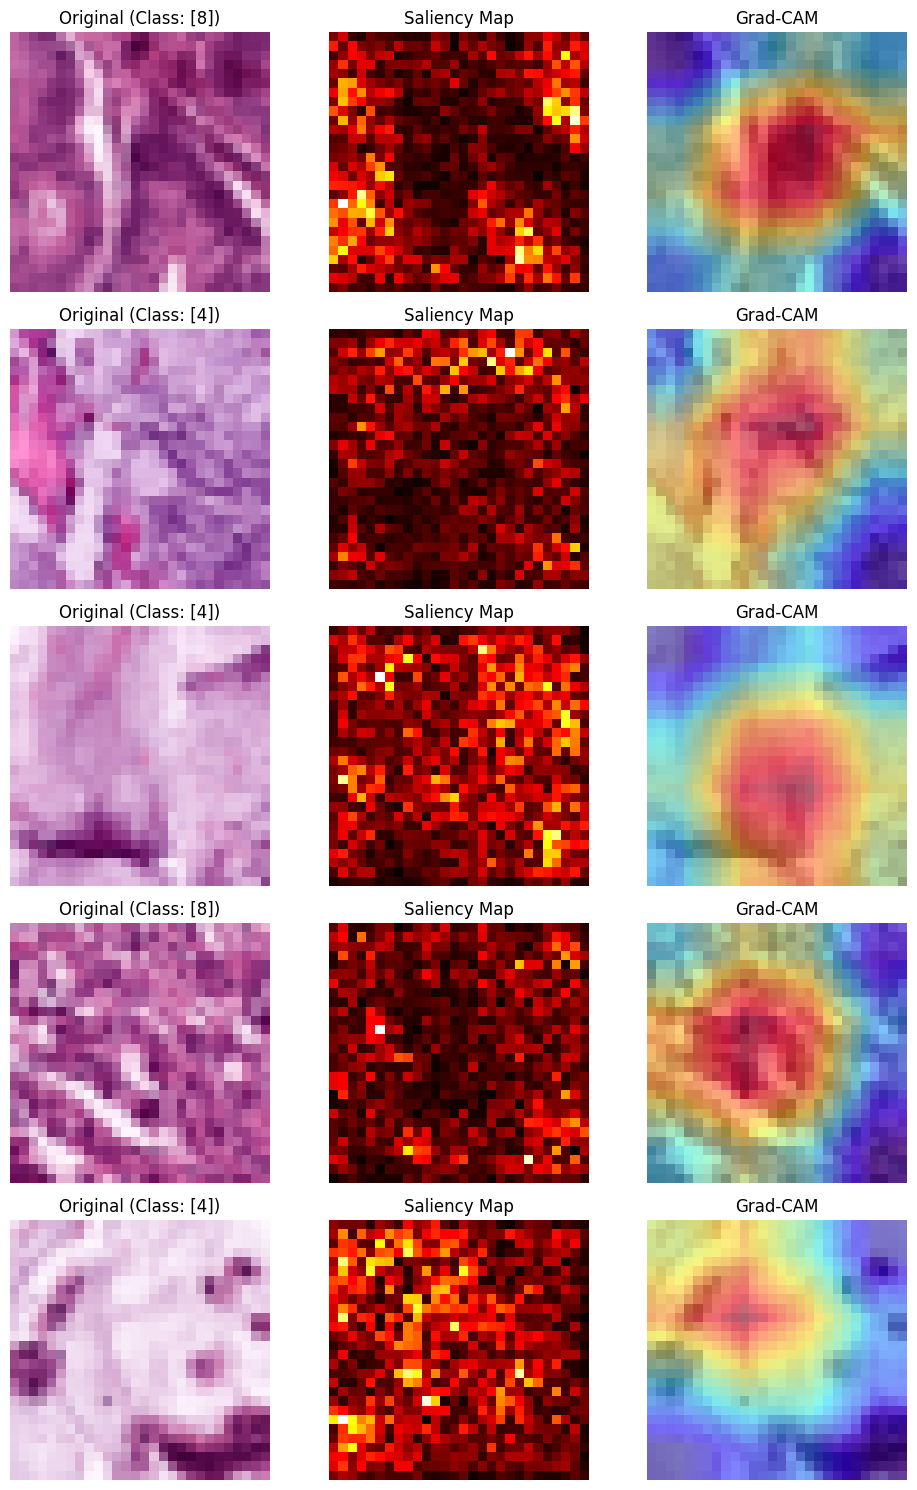

In [23]:
resnet_path = resnet18(num_classes=num_classes)
resnet_path.conv1 = torch.nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
resnet_path.maxpool = nn.Identity()

# we reload the weights
checkpoint = torch.load('/kaggle/working/models/PathMNIST_ResNet28_50.pth.tar', map_location=torch.device('cpu'))

if 'state_dict' in checkpoint:
    resnet_path.load_state_dict(checkpoint['state_dict'])
else:
    resnet_path.load_state_dict(checkpoint)

resnet_path.to(device)

# We choose to focus on the last layer as it probably contains the higher level features
visualize_explainability(resnet_path, test_dataset, resnet_path.layer4[-1], device, num_images=5)

**Answer**: For both networks, this is really difficult to find something meaningful, largely due to the low resolution of images.

First, saliency maps are just too noisy, but we could say that most of the time, for the modified net, the pixels that have the most influence on the model's prediction are the ones located in the middle. On the contrary, for ResNet18, those pixels are located along the edges of the images.

For Grad-CAM, we decided to focus on the last layer for both networks as they contain the highest level features. Results are really different, but is seems to work better for the modified Net, even if ResNet18 has a higher test accuracy. For example, for the third picture it identifies well the violet pixels on the top-right corner, or the circle on the left of the fifth image.

# II. DermaMNIST

In [24]:
dataset_name = "dermamnist"
SIZE_IMAGES=28
BATCH_SIZE = 32

train_dataset, val_dataset, test_dataset, train_loader, val_loader, test_loader, in_channels, num_classes, task = load_medmnist(dataset_name, BATCH_SIZE, SIZE_IMAGES)

print('The task is', task)
image_size = train_loader.dataset.imgs.shape[1]
print('The size of images is ', image_size)

100%|██████████| 19.7M/19.7M [00:01<00:00, 12.2MB/s]


The task is multi-class
The size of images is  28


## II.A. modified Net

In [99]:
model = modified_Net(in_channels=in_channels, num_classes=num_classes)

NUM_EPOCHS = 50
lr = 0.001
weight_decay = 0.01
patience = 10

trained_model = train_model(model, train_loader, val_loader, task, NUM_EPOCHS, lr, weight_decay, patience)

os.makedirs('models/', exist_ok=True)
filename = 'models/DermaMNIST_modNet'+ str(SIZE_IMAGES) +'_'+ str(NUM_EPOCHS) +'.pth.tar'
torch.save({
                'epoch': NUM_EPOCHS,
                'state_dict': trained_model.state_dict()
            }, filename)

y_true,pred = evaluate(trained_model, test_loader, task)

Epoch 1: 100%|██████████| 219/219 [00:03<00:00, 68.32it/s]


Loss: 0.9356 | Val Loss: 0.8584 | Val Acc: 69.29% | LR: 0.001
Model saved (improved val loss)


Epoch 2: 100%|██████████| 219/219 [00:03<00:00, 66.37it/s]


Loss: 0.8281 | Val Loss: 0.8059 | Val Acc: 70.19% | LR: 0.001
Model saved (improved val loss)


Epoch 3: 100%|██████████| 219/219 [00:03<00:00, 60.38it/s]


...

Loss: 0.4542 | Val Loss: 0.6684 | Val Acc: 74.98% | LR: 1.0000000000000002e-06
No improvement. Patience: 8/10


Epoch 32: 100%|██████████| 219/219 [00:03<00:00, 71.52it/s]


Loss: 0.4585 | Val Loss: 0.6681 | Val Acc: 75.07% | LR: 1.0000000000000002e-06
No improvement. Patience: 9/10


Epoch 33: 100%|██████████| 219/219 [00:03<00:00, 71.53it/s]


Loss: 0.4578 | Val Loss: 0.6695 | Val Acc: 75.37% | LR: 1.0000000000000002e-06
No improvement. Patience: 10/10
Early stopping triggered.
Loading best weights from best_model.pth...
Test Accuracy: 77.01%


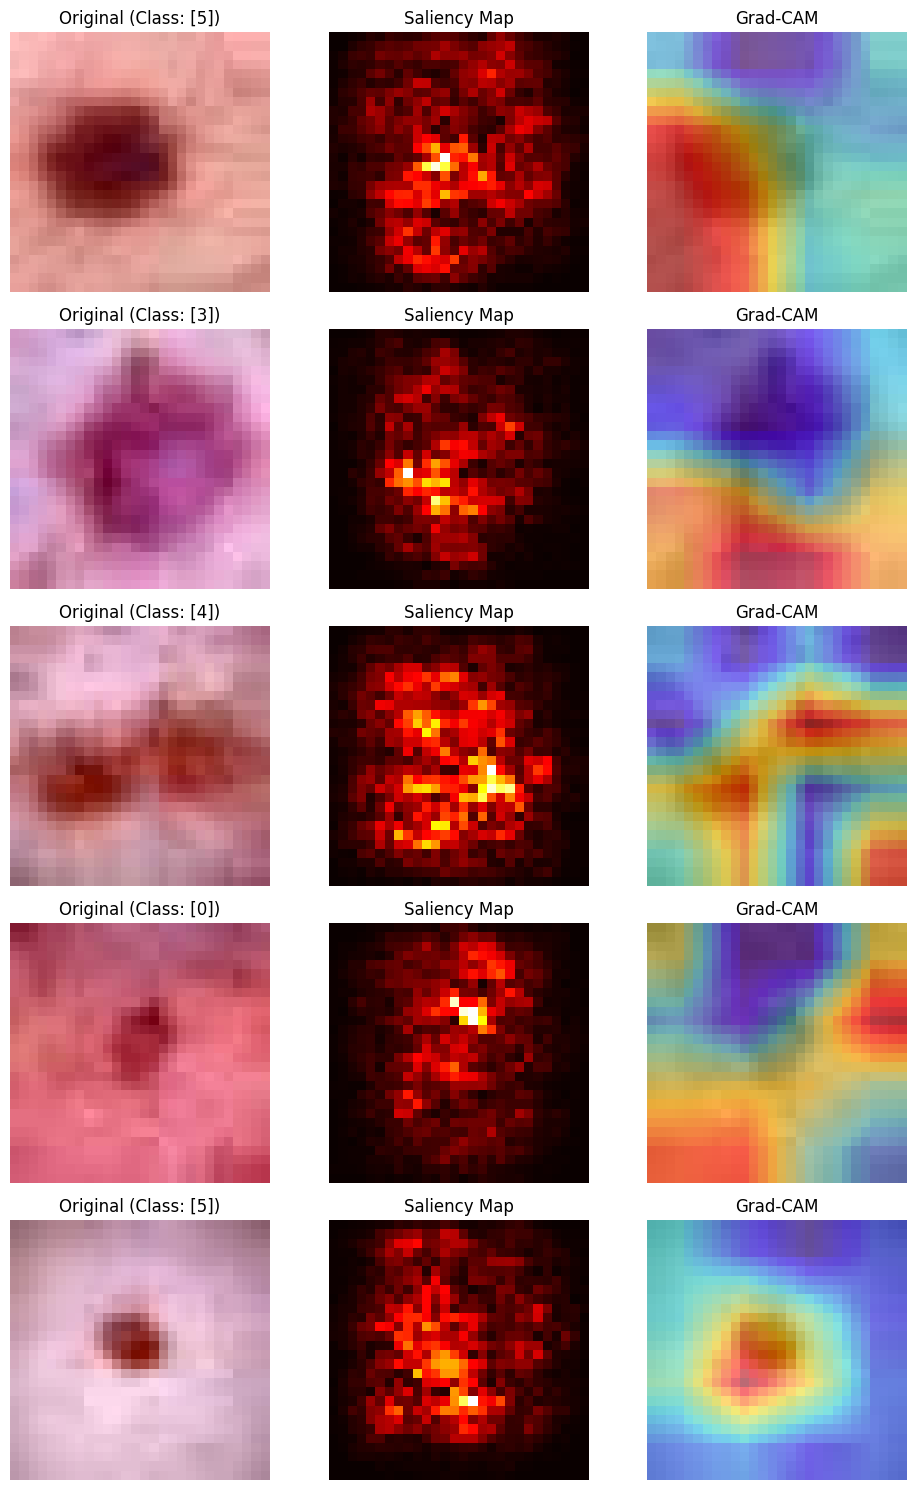

In [25]:
model_derma = modified_Net(in_channels=in_channels, num_classes=num_classes)

# we reload the weights
checkpoint = torch.load('/kaggle/input/models/paulrongieras/model-tp8/pytorch/default/1/DermaMNIST_modNet28_50.pth.tar', map_location=torch.device('cpu'))

if 'state_dict' in checkpoint:
    model_derma.load_state_dict(checkpoint['state_dict'])
else:
    model_derma.load_state_dict(checkpoint)

model_derma.to(device)

# We choose to focus on the last layer as it probably contains the higher level features
visualize_explainability(model_derma, test_dataset, model_derma.layer5, device, num_images=5)

## II.B. pre-trained ResNet18

In [116]:
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
model.maxpool = nn.Identity()

num_features = model.fc.in_features
model.fc = nn.Linear(num_features, num_classes)

NUM_EPOCHS = 50
lr = 0.001
weight_decay = 0.01
patience = 15

trained_model = train_model(model, train_loader, val_loader, task, NUM_EPOCHS, lr, weight_decay, patience)

os.makedirs('models/', exist_ok=True)
filename = 'models/DermaMNIST_ResNet'+ str(SIZE_IMAGES) +'_'+ str(NUM_EPOCHS) +'.pth.tar'
torch.save({
                'epoch': NUM_EPOCHS,
                'state_dict': trained_model.state_dict()
            }, filename)

y_true,pred = evaluate(trained_model, test_loader, task)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 163MB/s]
Epoch 1: 100%|██████████| 219/219 [00:06<00:00, 34.30it/s]


Loss: 0.9713 | Val Loss: 0.8050 | Val Acc: 69.29% | LR: 0.001
Model saved (improved val loss)


Epoch 2: 100%|██████████| 219/219 [00:05<00:00, 38.13it/s]


Loss: 0.8088 | Val Loss: 0.7305 | Val Acc: 72.88% | LR: 0.001
Model saved (improved val loss)


...

Loss: 0.0246 | Val Loss: 1.4174 | Val Acc: 72.28% | LR: 1.0000000000000002e-06
No improvement. Patience: 13/15


Epoch 19: 100%|██████████| 219/219 [00:05<00:00, 38.21it/s]


Loss: 0.0236 | Val Loss: 1.4371 | Val Acc: 72.78% | LR: 1.0000000000000002e-06
No improvement. Patience: 14/15


Epoch 20: 100%|██████████| 219/219 [00:06<00:00, 34.94it/s]


Loss: 0.0230 | Val Loss: 1.4159 | Val Acc: 72.88% | LR: 1.0000000000000002e-06
No improvement. Patience: 15/15
Early stopping triggered.
Loading best weights from best_model.pth...
Test Accuracy: 74.41%


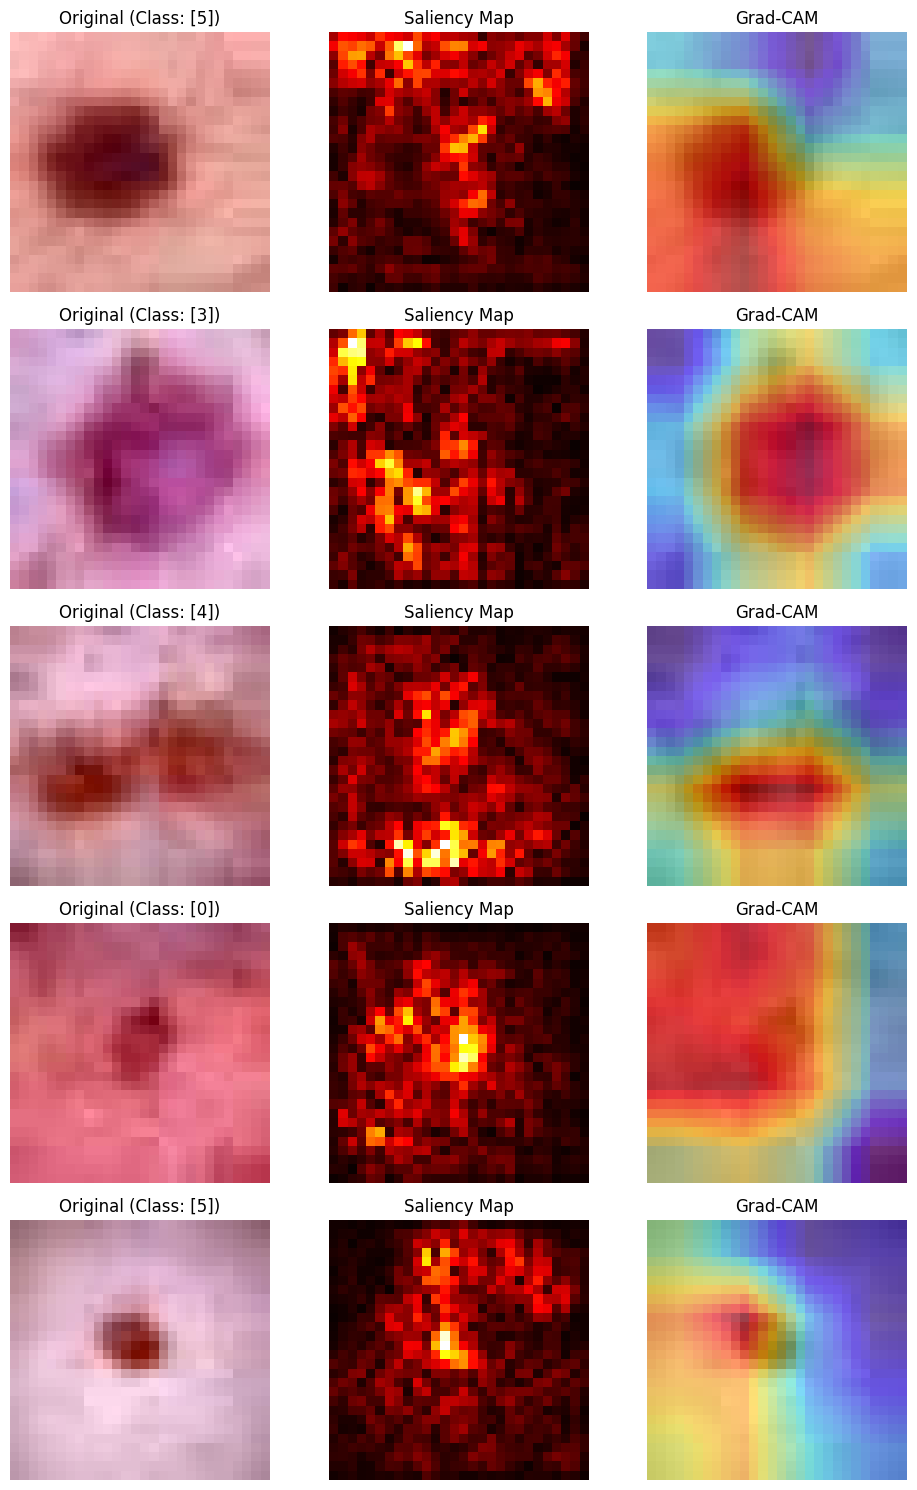

In [26]:
resnet_derma = resnet18(num_classes=num_classes)
resnet_derma.conv1 = torch.nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
resnet_derma.maxpool = nn.Identity()

# we reload the weights
checkpoint = torch.load('/kaggle/input/models/paulrongieras/model-tp8/pytorch/default/1/DermaMNIST_ResNet28_50.pth.tar', map_location=torch.device('cpu'))

if 'state_dict' in checkpoint:
    resnet_derma.load_state_dict(checkpoint['state_dict'])
else:
    resnet_derma.load_state_dict(checkpoint)

resnet_derma.to(device)

# We choose to focus on the last layer as it probably contains the higher level features
visualize_explainability(resnet_derma, test_dataset, resnet_derma.layer4[-1], device, num_images=5)

**Answer**: First of all, suprisingly, the modified Net obtains a higher test accuracy than the pre-trained ResNet18. This can be due to the random initialization of the first convolution layer of the pre-trained ResNet, to the small number of images in DermaMNIST or to the fact that ImageNet is really too far from DermaMNIST, and the ResNet should be trained on more epochs to adapt more its weights.

The saliency maps look good for both networks, this may be due to the simplicity of DermaMNIST images with a circle in the middle.

For Grad-CAM, it works remarkably well for ResNet18, but is is disappointing for the modified Net.